In [1]:
import pandas as pd
import yfinance as yf
import datetime
from datetime import date, timedelta
today = date.today()

In [3]:
d1 = today.strftime("%Y-%m-%d")
end_date = d1
d2 = date.today() - timedelta(days=5000)
d2 = d2.strftime("%Y-%m-%d")
start_date = d2

data = yf.download('AAPL', 
                      start=start_date, 
                      end=end_date, 
                      progress=False)
data["Date"] = data.index
data = data[["Date", "Open", "High", "Low", "Close", "Volume"]]
data.reset_index(drop=True, inplace=True)
data.tail()

Price,Date,Open,High,Low,Close,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
3436,2026-03-31,247.910004,255.479996,247.100006,253.789993,49598100
3437,2026-04-01,254.080002,256.179993,253.330002,255.630005,40059400
3438,2026-04-02,254.199997,256.130005,250.649994,255.919998,31289400
3439,2026-04-06,256.510010,262.160004,256.459991,258.859985,29329900
3440,2026-04-07,256.160004,256.200012,245.699997,253.500000,62148000


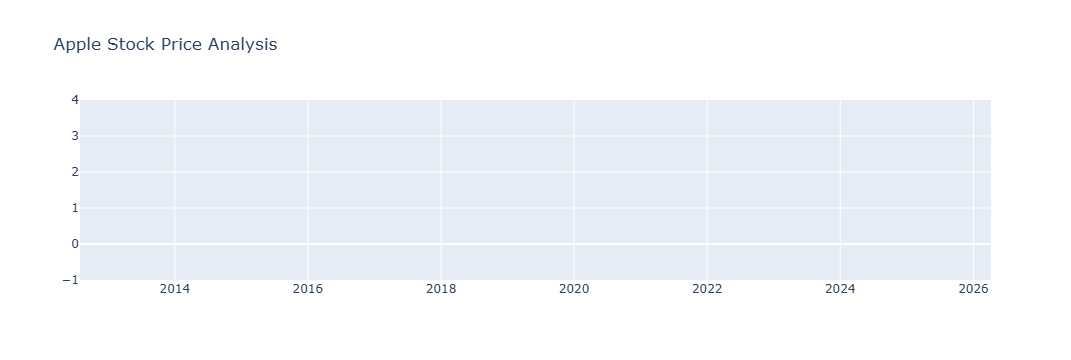

In [4]:
import plotly.graph_objects as go
figure = go.Figure(data=[go.Candlestick(x=data["Date"],
                                        open=data["Open"], 
                                        high=data["High"],
                                        low=data["Low"], 
                                        close=data["Close"])])
figure.update_layout(title = "Apple Stock Price Analysis", 
                     xaxis_rangeslider_visible=False)
figure.show()

In [8]:
# correlation["Close"] bir DataFrame ise, içinden ilgili sütunu seçip Series'e dönüştürürüz
close_corr = correlation["Close"]
# Eğer tek bir sütun varsa squeeze() ile Series yapabilirsiniz
print(close_corr.squeeze().sort_values(ascending=False))

Price   Ticker
Close   AAPL      1.000000
High    AAPL      0.999888
Low     AAPL      0.999886
Open    AAPL      0.999752
Volume  AAPL     -0.543824
Name: AAPL, dtype: float64


In [9]:
x = data[["Open", "High", "Low", "Volume"]]
y = data["Close"]
x = x.to_numpy()
y = y.to_numpy()
y = y.reshape(-1, 1)

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
from keras.models import Sequential
from keras.layers import Dense, LSTM
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (xtrain.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))
model.summary()

C:\Users\tamer\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 4, 128)              │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [15]:
# 1. En iyi modeli kaydetmek için Checkpoint
checkpoint = ModelCheckpoint(
    filepath='SM_LTSM_best.keras', # En iyi ağırlıkların kaydedileceği dosya adı
    monitor='val_loss',          # Neye bakarak "en iyi" diyecek? (Doğrulama kaybı)
    save_best_only=True,         # Sadece en düşük loss değerine sahip modeli kaydet
    verbose=1
)

# 2. Hata düşmediğinde eğitimi durdurmak için EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',          # Takip edilen değer
    patience=5,                  # Eğer 5 epoch boyunca val_loss düşmezse durdur
    restore_best_weights=True    # Durduğunda en iyi ağırlıklara geri dön
)

# 3. Modeli Eğitme (Validation_split ekleyerek)
history = model.fit(
    xtrain, ytrain, 
    batch_size=1, 
    epochs=50,
    validation_split=0.1,        # Verinin %10'unu test için ayır (callback'ler için şart)
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50
2474/2476 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.1917
Epoch 1: val_loss improved from None to 4.52760, saving model to SM_LTSM_best.keras

Epoch 1: finished saving model to SM_LTSM_best.keras
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 9.3935 - val_loss: 4.5276
Epoch 2/50
2469/2476 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.5172
Epoch 2: val_loss did not improve from 4.52760
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 10.3619 - val_loss: 6.5722
Epoch 3/50
2468/2476 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.2627
Epoch 3: val_loss did not improve from 4.52760
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 8.3227 - val_loss: 8.5205
Epoch 4/50
2471/2476 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.6604
Epoch 4: val_loss did not improve from 4.52760
2476/2476 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 10.1464 - val_loss: 9.6320
Epoch 5/50
2472/2476 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.7690
Epoch 5: val_loss improved from 4.52760 to 3.15541, saving 

In [19]:
import tensorflow as tf
import numpy as np

# 1. Veriyi hazırla (Son satırı alıyoruz)
son_veri = data[["Open", "High", "Low", "Volume"]].iloc[-1].values 

# 2. Veriyi önce numpy ile şekillendir
# Sizin modeliniz 4 özellikli tek bir adım bekliyor (batch_size=1, timesteps=4, features=1)
tahmin_girdisi_np = son_veri.reshape(1, 4, 1).astype('float32')

# 3. KRİTİK ADIM: Numpy dizisini açıkça bir Tensor'a dönüştür
# Bu adım "unknown rank" hatasını (boyut belirsizliğini) çözer
tahmin_girdisi_tensor = tf.convert_to_tensor(tahmin_girdisi_np)

# 4. Tahmin Yap
# predict fonksiyonu yerine doğrudan model çağrısını kullanmak bazen bu hatayı aşar
tahmin = model(tahmin_girdisi_tensor, training=False)

# Sonucu yazdır (Tensor nesnesinden numpy'a geri dönerek)
print(f"Modelin Tahmin Ettiği Kapanış Fiyatı: {tahmin.numpy()[0][0]}")

Modelin Tahmin Ettiği Kapanış Fiyatı: 248.0457763671875
